# Indicator 2: Obligation, Precision, and Delegation Scores
## Abbott et al. (2000) Three-Dimensional Legalization Framework

---

### About This Notebook

This notebook operationalizes **Indicator 2** of the empirical framework, addressing the first sub-question of the research:

> *"How have the obligation, precision, and delegation scores of key financial governance instruments changed from Basel I (1988) to Basel III (2017)?"*

Where Indicator 1 established the legal basis of the **institutions** in the banking governance complex, Indicator 2 examines the legal character of their **outputs** — the Basel Accords themselves. An institution can be informal in its constitutional form while producing outputs that vary significantly in how precisely they specify required conduct and how extensively they delegate monitoring authority. Indicator 2 captures this variation.

---

### Theoretical Framework

Abbott, Keohane, Moravcsik, Slaughter, and Snidal (2000) define legalization as a set of characteristics that governance arrangements may possess, measured along three conceptually **independent** dimensions:

| Dimension | Definition | Scale |
|---|---|---|
| **Obligation** | Whether actors are legally bound by the instrument — subject to scrutiny under international law | LOW / MEDIUM / HIGH |
| **Precision** | How specifically the instrument defines the conduct required or proscribed | LOW / MEDIUM / HIGH |
| **Delegation** | Whether third parties hold authority to implement, interpret, apply, or enforce the rules | LOW / MEDIUM / HIGH |

The **independence** of these dimensions is the framework's critical analytical contribution. An arrangement can score LOW on obligation while scoring VERY HIGH on precision — and that is precisely the pattern the Basel sequence is expected to exhibit. This combination — codification without legalization — is the central empirical claim of the paper.

---

### What This Notebook Does

This notebook proceeds in five steps:

1. **Documents the primary source** for each Basel Accord retrieved from the BIS website and stored in `Data Sources/`
2. **Applies Abbott et al. scoring** on all three dimensions to Basel I (1988), Basel II (2004), and Basel III (2010/2017), with explicit textual justification for each score
3. **Constructs a structured dataset** recording the scores longitudinally across the three accords
4. **Visualizes the trajectory** of obligation, precision, and delegation across the Basel sequence
5. **Identifies the codification-without-legalization signature** — the divergence between rising precision and stable low obligation

---

### Instruments Scored

| Instrument | Year | Primary Source |
|---|---|---|
| Basel I — International Convergence of Capital Measurement and Capital Standards | 1988 | BIS (bis.org/publ/bcbs04a.pdf) |
| Basel II — International Convergence of Capital Measurement and Capital Standards: A Revised Framework | 2004 | BIS (bis.org/publ/bcbs128.pdf) |
| Basel III — A Global Regulatory Framework for More Resilient Banks and Banking Systems | 2010/2017 | BIS (bis.org/bcbs/publ/d424.pdf) |

---

### Output

The notebook produces:
- `outputs/indicator2_abbott_scoring.csv` — the scored dataset across all three dimensions and three accords
- `outputs/figures/indicator2_legalization_trajectory.png` — trajectory visualization showing the divergence between obligation and precision across the Basel sequence

In [1]:
# Core libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Ensure output directories exist
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

print("Libraries imported successfully.")
print(f"Output directories ready.")

Libraries imported successfully.
Output directories ready.


In [2]:
# Abbott et al. (2000) scoring applied to Basel I, II, and III
# Each score is accompanied by explicit textual justification
# drawn from the primary source documents

# Numeric mapping for visualization
score_map = {"LOW": 1, "LOW-MEDIUM": 2, "MEDIUM": 3, "HIGH": 4, "VERY HIGH": 5}

accords = [
    {
        "accord": "Basel I",
        "year": 1988,
        "full_title": "International Convergence of Capital Measurement and Capital Standards",
        "source": "bcbs04a.pdf",

        # OBLIGATION
        "obligation_score": "LOW",
        "obligation_justification": (
            "Basel I contains no binding legal language. The document opens with the "
            "Committee presenting its framework as a recommendation, not an obligation. "
            "No ratification procedure exists. The 8% capital ratio is presented as a "
            "target, not a legal requirement. Member states adopt it through domestic "
            "legislation at their discretion. Explicitly soft law."
        ),

        # PRECISION
        "precision_score": "LOW-MEDIUM",
        "precision_justification": (
            "Basel I specifies a single capital adequacy ratio of 8% of risk-weighted "
            "assets, with four broad risk-weight categories: 0% (sovereign), 20% (banks), "
            "50% (mortgages), 100% (corporate). The framework is relatively simple — "
            "fewer than 30 pages of operative provisions. Significant national discretion "
            "remains in how risk weights are applied domestically. Precision is higher "
            "than aspirational soft law but far below the technical elaboration of later accords."
        ),

        # DELEGATION
        "delegation_score": "LOW",
        "delegation_justification": (
            "Basel I establishes no monitoring body, no peer review mechanism, and no "
            "reporting requirements to an independent third party. Compliance is "
            "entirely self-reported. No dispute settlement mechanism exists. The BCBS "
            "itself has no enforcement authority. Delegation is as low as it can be "
            "while any governance arrangement still exists."
        ),
    },
    {
        "accord": "Basel II",
        "year": 2004,
        "full_title": "International Convergence of Capital Measurement and Capital Standards: A Revised Framework",
        "source": "bcbs128.pdf",

        # OBLIGATION
        "obligation_score": "LOW",
        "obligation_justification": (
            "Basel II retains the identical constitutional status as Basel I — non-binding, "
            "no ratification, no treaty basis. The framework explicitly states it is "
            "addressed to internationally active banks and that national supervisors "
            "retain full discretion over implementation. Obligation score is unchanged "
            "from Basel I despite the dramatic increase in technical elaboration."
        ),

        # PRECISION
        "precision_score": "HIGH",
        "precision_justification": (
            "Basel II introduces the three-pillar architecture: Pillar 1 (minimum capital "
            "requirements), Pillar 2 (supervisory review), Pillar 3 (market discipline). "
            "Pillar 1 alone introduces the Internal Ratings-Based (IRB) approach, "
            "operational risk capital charges, and detailed risk-weighting formulas. "
            "The framework runs to over 250 pages of operative provisions. Precision "
            "increases dramatically — specific formulas, probability of default calculations, "
            "loss-given-default parameters. National discretion is reduced relative to Basel I "
            "but remains significant through the IRB approach."
        ),

        # DELEGATION
        "delegation_score": "LOW-MEDIUM",
        "delegation_justification": (
            "Basel II introduces BCBS working groups that informally monitor national "
            "implementation progress. The IMF begins incorporating Basel compliance "
            "into FSAP assessments during this period. However, no formal peer review "
            "mechanism exists yet and monitoring remains largely voluntary. A modest "
            "step toward delegation without reaching formal third-party enforcement."
        ),
    },
    {
        "accord": "Basel III",
        "year": 2010,
        "full_title": "A Global Regulatory Framework for More Resilient Banks and Banking Systems",
        "source": "d424.pdf",

        # OBLIGATION
        "obligation_score": "LOW",
        "obligation_justification": (
            "Basel III remains constitutionally identical to its predecessors — soft law, "
            "no treaty, no ratification, no binding legal force. The 2017 consolidated "
            "framework makes no change to the legal status of the accord. Despite the "
            "dramatic strengthening of prudential content after the 2008 crisis, the "
            "obligation score does not move. This is the central empirical finding: "
            "the most ambitious prudential standard ever produced by the BCBS carries "
            "precisely the same legal weight as a G20 communique."
        ),

        # PRECISION
        "precision_score": "VERY HIGH",
        "precision_justification": (
            "Basel III specifies: Common Equity Tier 1 (CET1) at 4.5% of risk-weighted "
            "assets; Tier 1 capital at 6%; Total capital at 8%; Capital Conservation "
            "Buffer at 2.5%; Countercyclical Capital Buffer of 0-2.5%; Leverage Ratio "
            "of 3%; Liquidity Coverage Ratio (LCR) of 100%; Net Stable Funding Ratio "
            "(NSFR) of 100%; G-SIB surcharges of 1-3.5%. The consolidated 2017 framework "
            "runs to over 1,700 pages including technical annexes. Precision reaches its "
            "maximum — ratios specified to decimal points, methodologies fully prescribed."
        ),

        # DELEGATION
        "delegation_score": "MEDIUM",
        "delegation_justification": (
            "Basel III introduces the Regulatory Consistency Assessment Programme (RCAP) "
            "in 2012 — the first formal peer review mechanism in BCBS history. RCAP "
            "produces public jurisdiction-specific compliance reports with explicit "
            "ratings (Compliant / Largely Compliant / Materially Non-Compliant). IMF "
            "FSAPs become mandatory for G20 members post-2010. FSB peer reviews add "
            "a second monitoring layer. However, none of these mechanisms carry "
            "enforcement authority — naming and shaming is the limit of their power. "
            "Delegation is meaningful but stops well short of binding enforcement."
        ),
    }
]

df = pd.DataFrame(accords)

# Add numeric scores for visualization
df["obligation_numeric"] = df["obligation_score"].map(score_map)
df["precision_numeric"] = df["precision_score"].map(score_map)
df["delegation_numeric"] = df["delegation_score"].map(score_map)

print(df[["accord", "year", "obligation_score", "precision_score", "delegation_score"]])

      accord  year obligation_score precision_score delegation_score
0    Basel I  1988              LOW      LOW-MEDIUM              LOW
1   Basel II  2004              LOW            HIGH       LOW-MEDIUM
2  Basel III  2010              LOW       VERY HIGH           MEDIUM


### Scoring Results — Significance for the Paper

This table is the empirical core of **Focal Point A**. Three decades of Basel standard-setting 
produced a clear and consistent pattern across all three accords:

- **Obligation:** Flat at LOW across the entire sequence. Basel III — the most technically 
elaborate prudential standard ever produced — carries precisely the same legal weight as 
Basel I. The 2008 crisis, which triggered the most ambitious regulatory reform in post-war 
financial history, did not move the obligation score by a single increment.

- **Precision:** Steep and consistent rise — LOW-MEDIUM → HIGH → VERY HIGH. The Basel 
sequence became dramatically more elaborate with each iteration, specifying conduct in 
increasing technical detail across hundreds, then thousands, of pages.

- **Delegation:** Modest rise — LOW → LOW-MEDIUM → MEDIUM. The introduction of RCAP 
in 2012 represents the only structural innovation in the delegation dimension across the 
entire sequence. Even at MEDIUM, delegation stops well short of binding enforcement.

This is the **codification without legalization** signature. The gap between precision and 
obligation widens with each accord — reaching its maximum at Basel III, which is 
simultaneously the most precisely specified and the most non-complied-with accord in the sequence.

In [3]:
# Save scored dataset to outputs
df.to_csv("../outputs/indicator2_abbott_scoring.csv", index=False)

print("Dataset saved to: ../outputs/indicator2_abbott_scoring.csv")
print(f"Accords scored: {len(df)}")
print(f"Dimensions scored: Obligation, Precision, Delegation")

Dataset saved to: ../outputs/indicator2_abbott_scoring.csv
Accords scored: 3
Dimensions scored: Obligation, Precision, Delegation


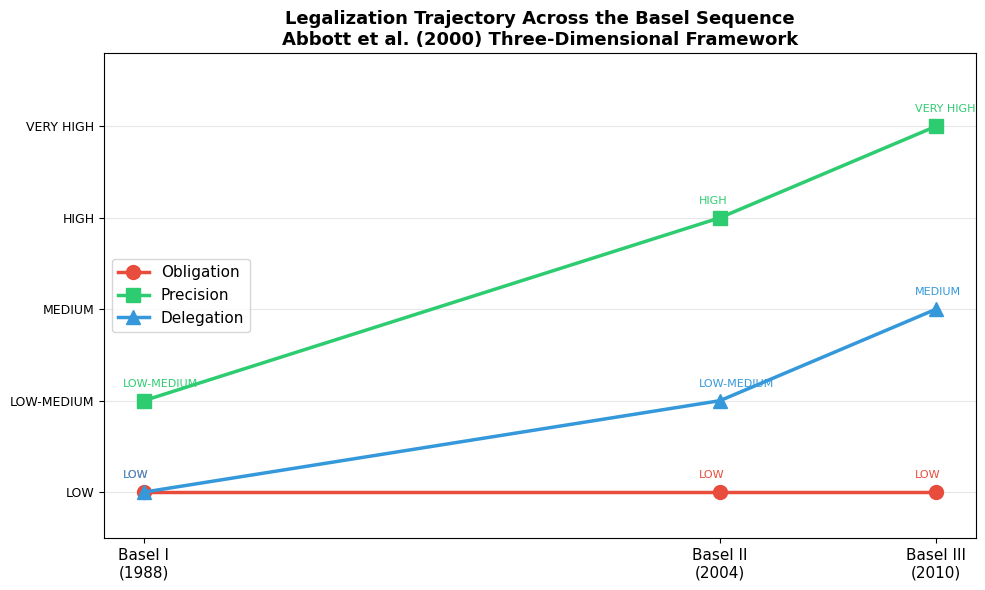

Figure saved to: ../outputs/figures/indicator2_legalization_trajectory.png


In [4]:
# Trajectory visualization — obligation, precision, delegation across Basel sequence

fig, ax = plt.subplots(figsize=(10, 6))

years = df["year"].tolist()
obligation = df["obligation_numeric"].tolist()
precision = df["precision_numeric"].tolist()
delegation = df["delegation_numeric"].tolist()

# Plot trajectories
ax.plot(years, obligation, marker="o", linewidth=2.5, markersize=10,
        color="#e74c3c", label="Obligation")
ax.plot(years, precision, marker="s", linewidth=2.5, markersize=10,
        color="#2ecc71", label="Precision")
ax.plot(years, delegation, marker="^", linewidth=2.5, markersize=10,
        color="#3498db", label="Delegation")

# Score labels on each point
for i, row in df.iterrows():
    ax.annotate(row["obligation_score"], (row["year"], row["obligation_numeric"]),
                textcoords="offset points", xytext=(-15, 10), fontsize=8, color="#e74c3c")
    ax.annotate(row["precision_score"], (row["year"], row["precision_numeric"]),
                textcoords="offset points", xytext=(-15, 10), fontsize=8, color="#2ecc71")
    ax.annotate(row["delegation_score"], (row["year"], row["delegation_numeric"]),
                textcoords="offset points", xytext=(-15, 10), fontsize=8, color="#3498db")

# Formatting
ax.set_xticks(years)
ax.set_xticklabels(["Basel I\n(1988)", "Basel II\n(2004)", "Basel III\n(2010)"], fontsize=11)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["LOW", "LOW-MEDIUM", "MEDIUM", "HIGH", "VERY HIGH"], fontsize=9)
ax.set_ylim(0.5, 5.8)
ax.set_title(
    "Legalization Trajectory Across the Basel Sequence\nAbbott et al. (2000) Three-Dimensional Framework",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=11, loc="center left")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/indicator2_legalization_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved to: ../outputs/figures/indicator2_legalization_trajectory.png")

### Figure 2 — Legalization Trajectory Across the Basel Sequence

This figure is the visual centrepiece of **Focal Point A**. Three trajectories tell 
three distinct stories:

The **flat red line** — obligation frozen at LOW across three decades and three major 
accords — is the most important finding. No crisis, no reform agenda, no political 
commitment moved it. Basel III, produced in direct response to the most severe financial 
crisis since 1929, carries identical legal force to Basel I: none.

The **steeply rising green line** — precision climbing from LOW-MEDIUM to VERY HIGH — 
captures the paradox. The Basel architecture became exponentially more elaborate while 
remaining constitutionally unchanged. More rules, more detail, more pages — and zero 
additional legal bite.

The **modestly rising blue line** — delegation moving from LOW to MEDIUM — reflects the 
one genuine institutional innovation of the Basel III era: the introduction of RCAP in 
2012. But MEDIUM delegation with LOW obligation produces naming and shaming, not 
enforcement. The gap between what the BCBS can observe and what it can compel remains 
structurally unbridgeable.

The divergence between precision and obligation — widest at Basel III — is the 
empirical signature of codification without legalization. It sets up the compliance 
gap documented in Indicator 3: when an architecture is maximally precise but carries 
no legal obligation, compliance becomes a political choice, not a legal requirement.